In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('../trash_hauler_report.csv')

In [7]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20226 entries, 0 to 20225
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Request Number    20226 non-null  int64  
 1   Date Opened       20226 non-null  object 
 2   Request           20226 non-null  object 
 3   Description       20195 non-null  object 
 4   Incident Address  20217 non-null  object 
 5   Zip Code          20151 non-null  float64
 6   Trash Hauler      19325 non-null  object 
 7   Trash Route       19279 non-null  object 
 8   Council District  20177 non-null  float64
 9   State Plan X      20198 non-null  float64
 10  State Plan Y      20198 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1.7+ MB


,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1.727970e+06,686779.478089
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
zip_col = pd.to_numeric(df['Zip Code'], errors='coerce')
df['Zip Code'] = zip_col.fillna(0).astype('int64') 

In [10]:
cd_col = pd.to_numeric(df['Council District'], errors='coerce')
df['Council District'] = cd_col.fillna(0).astype('int64')

In [11]:
tr_col = pd.to_numeric(df['Trash Route'], errors='coerce')
df['Trash Route'] = tr_col.fillna(0).astype('int64')

In [12]:
df = df.drop_duplicates()
df

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2,1.727970e+06,686779.478089
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207,WASTE IND,2206,2,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209,RED RIVER,4203,20,1.710186e+06,664205.101066
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013,RED RIVER,4502,32,1.781137e+06,632448.551144
20222,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206,METRO,9508,6,1.749711e+06,669201.601569
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214,RED RIVER,1502,15,1.770293e+06,674936.303809
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013,RED RIVER,4502,32,1.785225e+06,627146.400187


In [13]:
df['Missed Count'] = df['Description'].str.contains('miss', case=False, na=False)
count_by_address = df.groupby('Incident Address')['Missed Count'].sum().reset_index()
print(count_by_address)

                                        Incident Address  Missed Count
0                        , Nashville, TN , United States             0
1                                  1 BELLE FORREST AVE C             1
2                                   10 Belle Forrest Ave             1
3      100 Bluefield Square, Nashville, TN 37214, Uni...             1
4                                    100 Braxton Hill Ct             1
...                                                  ...           ...
14116                           compton ave & 15th ave s             0
14117                                      fransworth dr             1
14118                           s 13th st  & woodland st             0
14119                          trimble rd & lindawood dr             0
14120                                          xavier dr             0

[14121 rows x 2 columns]


In [14]:
all_missed = df.loc[
    (df['Description'].str.contains('miss', case=False, na=False)) |
    (df['Request '].str.contains('miss', case=False, na=False))
]
print(all_missed)

       Request Number Date Opened                              Request   \
1               25274    11/01/17  Trash - Curbside/Alley Missed Pickup   
2               25276    11/01/17  Trash - Curbside/Alley Missed Pickup   
3               25307    11/01/17  Trash - Curbside/Alley Missed Pickup   
4               25312    11/01/17  Trash - Curbside/Alley Missed Pickup   
7               25327    11/01/17            Trash Collection Complaint   
...               ...         ...                                   ...   
20221          267125    11/01/19  Trash - Curbside/Alley Missed Pickup   
20222          267126    11/01/19  Trash - Curbside/Alley Missed Pickup   
20223          267130    11/01/19  Trash - Curbside/Alley Missed Pickup   
20224          267134    11/01/19  Trash - Curbside/Alley Missed Pickup   
20225          267137    11/01/19  Trash - Curbside/Alley Missed Pickup   

                                             Description  \
1                               Curb/Tr

In [15]:
df['Description'] = df['Description'].fillna('').astype(str)
df['Request '] = df['Request '].fillna('').astype(str)

all_missed = df.loc[
    (df['Description'].str.contains('miss', case=False, na=False)) | 
    (df['Request '].str.contains('miss', case=False, na=False))
].copy() 

all_missed['Missed Count'] = all_missed.apply(
    lambda row: 1 if 'miss' in str(row['Description']).lower() else 0, axis=1
) + all_missed.apply(
    lambda row: 1 if 'miss' in str(row['Request ']).lower() else 0, axis=1
)

all_missed['Total Fine'] = (all_missed['Missed Count'] - 1) * 200  
all_missed['Total Fine'] = all_missed['Total Fine'].clip(lower=0)  

print(all_missed)



       Request Number Date Opened                              Request   \
1               25274    11/01/17  Trash - Curbside/Alley Missed Pickup   
2               25276    11/01/17  Trash - Curbside/Alley Missed Pickup   
3               25307    11/01/17  Trash - Curbside/Alley Missed Pickup   
4               25312    11/01/17  Trash - Curbside/Alley Missed Pickup   
7               25327    11/01/17            Trash Collection Complaint   
...               ...         ...                                   ...   
20221          267125    11/01/19  Trash - Curbside/Alley Missed Pickup   
20222          267126    11/01/19  Trash - Curbside/Alley Missed Pickup   
20223          267130    11/01/19  Trash - Curbside/Alley Missed Pickup   
20224          267134    11/01/19  Trash - Curbside/Alley Missed Pickup   
20225          267137    11/01/19  Trash - Curbside/Alley Missed Pickup   

                                             Description  \
1                               Curb/Tr

In [16]:
grand_total = all_missed['Total Fine'].sum()
print(f"Total amount owed due to missed pickups: ${grand_total}")

Total amount owed due to missed pickups: $2063800


In [31]:
df.info()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y,Missed Count
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207,RED RIVER,3205,2,1.727970e+06,686779.478089,False
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218,RED RIVER,4202,1,1.721259e+06,685444.799565,True
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209,RED RIVER,4205,20,1.707027e+06,659887.471571,True
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207,WASTE IND,2206,2,1.735692e+06,685027.245923,True
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209,RED RIVER,4203,20,1.710186e+06,664205.101066,True
...,...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013,RED RIVER,4502,32,1.781137e+06,632448.551144,True
20222,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206,METRO,9508,6,1.749711e+06,669201.601569,False
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214,RED RIVER,1502,15,1.770293e+06,674936.303809,True
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013,RED RIVER,4502,32,1.785225e+06,627146.400187,True


Make a heat map that shows the most total missed pick ups and another that shows the total fines, each by zip code.

In [47]:
df_missed = df[df['Missed Count'] == True].groupby('Zip Code', as_index=False).size()
df_missed.columns = ['Zip Code', 'total_missed_pickups']

In [65]:
df_missed['total_fines'] = df_missed['total_missed_pickups'].apply(lambda x: max(0, (x - 1) * 200))

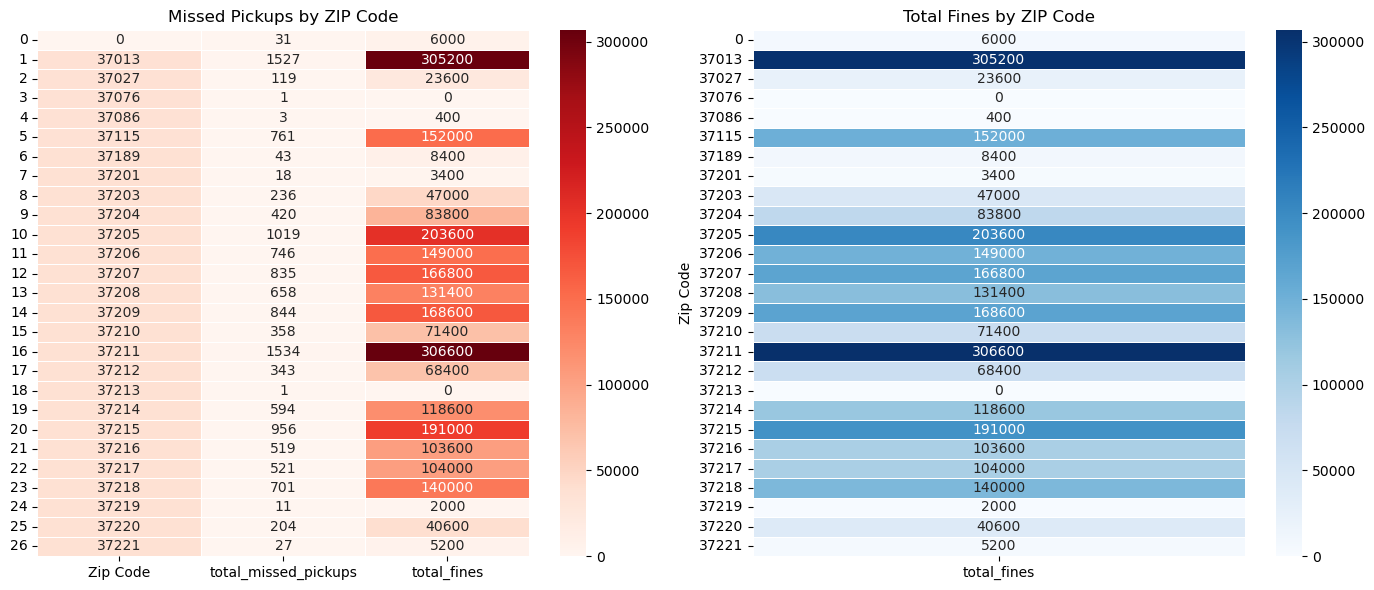

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

df_missed_pivot = df_missed.set_index('Zip Code')[['total_missed_pickups']]
df_fines_pivot = df_missed.set_index('Zip Code')[['total_fines']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(df_missed, cmap='Reds', annot=True, fmt='d', linewidths=0.5, ax=axes[0])
axes[0].set_title('Missed Pickups by ZIP Code')

sns.heatmap(df_fines_pivot, cmap='Blues', annot=True, fmt='d', linewidths=0.5, ax=axes[1])
axes[1].set_title('Total Fines by ZIP Code')

plt.tight_layout()
plt.show()

How do metro crews compare to the contractor's performance?

In [139]:
df['Trash Hauler'] = df['Trash Hauler'].str.lower()

df_metro = df[df['Trash Hauler'] == 'metro']
df_contractors = df[df['Trash Hauler'] != 'metro']


In [141]:
metro_missed = df_metro[df_metro['Missed Count'] == True].shape[0]

contractor_missed = df_contractors[df_contractors['Missed Count'] == True].shape[0]


In [143]:
metro_missed_counts = df_metro[df_metro['Missed Count'] == True].groupby('Zip Code').size()
metro_fines = (metro_missed_counts - 1).clip(lower=0).sum() * 200 

contractor_missed_counts = df_contractors[df_contractors['Missed Count'] == True].groupby('Zip Code').size()
contractor_fines = (contractor_missed_counts - 1).clip(lower=0).sum() * 200


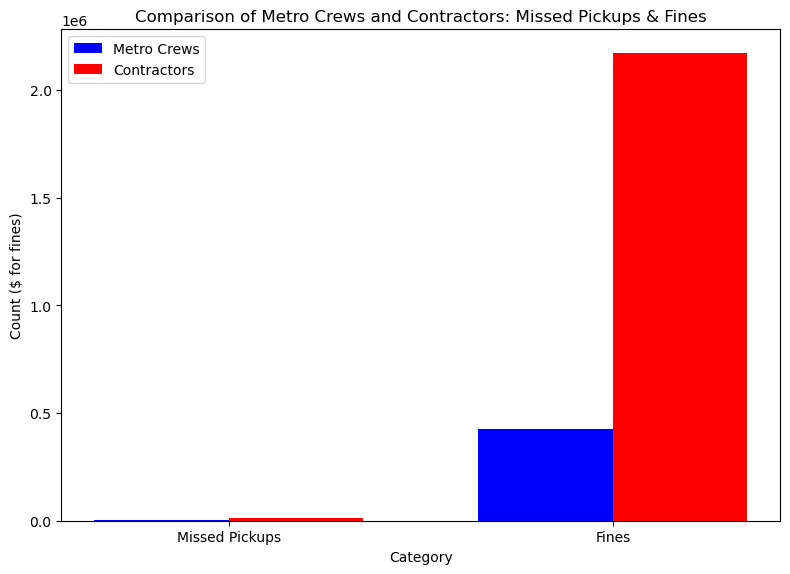

In [145]:
import matplotlib.pyplot as plt

categories = ['Missed Pickups', 'Fines']
metro_values = [metro_missed, metro_fines]
contractor_values = [contractor_missed, contractor_fines]

fig, ax = plt.subplots(figsize=(8, 6))
bar_width = 0.35
index = range(len(categories))

plt.bar(index, metro_values, bar_width, label='Metro Crews', color='blue')
plt.bar([i + bar_width for i in index], contractor_values, bar_width, label='Contractors', color='red')

plt.xlabel('Category')
plt.ylabel('Count ($ for fines)')
plt.title('Comparison of Metro Crews and Contractors: Missed Pickups & Fines')
plt.xticks([i + bar_width / 2 for i in index], categories)
plt.legend()
plt.tight_layout()
plt.show()



How much does each trash hauler owe?

In [107]:
df_missed_per_hauler = df[df['Missed Count'] == True].groupby('Trash Hauler').size().reset_index(name='total_missed_pickups')

In [109]:
df_missed_per_hauler['total_fines'] = df_missed_per_hauler['total_missed_pickups'].apply(lambda x: max(0, (x - 1) * 200))

In [111]:
df_missed_per_hauler['total_amount_owed'] = df_missed_per_hauler['total_fines']

In [117]:
print(df_missed_per_hauler)
grand_total = all_missed['Total Fine'].sum()
print(f"Total amount owed due to missed pickups: ${grand_total}")

  Trash Hauler  total_missed_pickups  total_fines  total_amount_owed
0        METRO                  2118       423400             423400
1        Metro                    22         4200               4200
2    RED RIVER                  9586      1917000            1917000
3    WASTE IND                   791       158000             158000
Total amount owed due to missed pickups: $2063800


Total Missed Pickups By Route

In [149]:
df_missed = df[df['Missed Count'] == True]

missed_by_route = df_missed.groupby('Trash Route').size().reset_index(name='total_missed_pickups')

print(missed_by_route)


     Trash Route  total_missed_pickups
0              0                   748
1           1201                   131
2           1202                    70
3           1203                    50
4           1204                    46
..           ...                   ...
145         9504                    29
146         9505                    37
147         9506                    48
148         9507                    54
149         9508                    81

[150 rows x 2 columns]
